In [ ]:
from huggingface_hub import login
login(token="HF_Tokens")


In [2]:
# load the Llama3 8B model
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer , AutoModelForCausalLM
import seaborn as sns


In [3]:
model_name = "meta-llama/Llama-3.1-8B"
Tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name,dtype = torch.float16, device_map = "auto")


config.json:   0%|          | 0.00/826 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

In [4]:
def visualize_gqa_keys_correct_mapping(input = "Hello lama!" , layer_idx=0):
    #token input
    input = Tokenizer(input , return_tensors = "pt").to(model.device)
    # hook
    k_values = []
    def k_projection_hook(module , input , output):
        print("Inside hook!")
        print("K projection shape:", output.shape)
        k_values.append(output.detach().cpu())

    # get first layer
    layer = model.model.layers[layer_idx]
    # add hook in k_projection layer (we can say camera which save output in k_value)
    k_hook = layer.self_attn.k_proj.register_forward_hook(k_projection_hook)

    # forward pas

    import inspect
    print(inspect.signature(model.forward))
    with torch.no_grad():
        _ = model(**input)
    k_hook.remove()

    k = k_values[0]  # shape : [batch ,seq lenght,kv_dim ]
    batch_size, seq_len , kv_dim = k.shape
    print (k.shape)

    # get model config
    num_query_heads = model.config.num_attention_heads       # 32    divisible of 32 is 2,8,16,32 and in 8 we get good ratio 32%8 which is 4 so 4 QUERIES SHARE SAME KEY AND VALUES SO 8 group have 4 heads which share kv cache
    num_kv_heads = model.config.num_key_value_heads       # 8
    head_dim  = kv_dim // num_kv_heads                  # 1024/8 = 128

    # reshape
    k_head = k.reshape(batch_size , seq_len , num_kv_heads , head_dim).transpose(-2,-3)
    print(k_head.shape)


    #build mapping  which Q head uses which KV head.   key=Q head   value = K head     Q → K
    q_to_kv_map = { q: q // (num_query_heads // num_kv_heads)     # q//(32//8) = q//4
                   for q in range(num_query_heads)                # as number of query heads are 32 so it run form 0 to 31
    }


    # Group Q heads by shared KV
    #"For each K_head, collect all the Q heads that use it. K→ Qs  #
    #KV0 → [Q0,Q1,Q2,Q3]

    kv_group = {}
    for q_head , key_head in q_to_kv_map.items():          # FIRST ITERATION (0,0) query is 0 & Key is 1(0,0) for second iteration Q = 1 , Key is 0(0,1) ans do on
        kv_group.setdefault(key_head , []).append(q_head)  # Give me the list belonging to this key_head. If it doesn't exist yet, create an empty list , kv_head = key , [] = default value key_head  :0 , value is 0 so {K0:[Q0,Q1,Q2,Q3],.... K7:[Q28,Q29,Q30,Q31]} , 1K shared by 4 Q heads
    print(kv_group)

# === Visualization ===

    plt.figure(figsize=(20, 2.5 * len(kv_group)))
    for row_idx, (kv_id, q_heads) in enumerate(kv_group.items()):
        for i, q_head in enumerate(q_heads):
            # All these Q heads share KV head `kv_id`
            key_matrix = k_head[0, kv_id, 0:1, :20]
            plt.subplot(
                len(kv_group),
                len(q_heads),
                row_idx * len(q_heads) + i + 1
            )
            sns.heatmap(
                key_matrix,
                cmap='coolwarm',
                cbar=False
            )
            plt.title(
                f"Group {kv_id} - Q{q_head}",
                fontsize=10
            )

            plt.xticks([])
            plt.yticks([])


    plt.suptitle(
    f"Key Matrix per Query Head "
    f"(first token × 20 dims)\n"
    f"LLaMA-3-8B Layer {layer_idx}",
    fontsize=14
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    plt.savefig(
    f"llama3_layer_{layer_idx}_gqa_keys.png"
    )
    plt.show()


(input_ids: torch.LongTensor | None = None, attention_mask: torch.Tensor | None = None, position_ids: torch.LongTensor | None = None, past_key_values: transformers.cache_utils.Cache | None = None, inputs_embeds: torch.FloatTensor | None = None, labels: torch.LongTensor | None = None, use_cache: bool | None = None, logits_to_keep: int | torch.Tensor = 0, **kwargs: Unpack[transformers.utils.generic.TransformersKwargs]) -> transformers.modeling_outputs.CausalLMOutputWithPast
Inside hook!
K projection shape: torch.Size([1, 9, 1024])
torch.Size([1, 9, 1024])
torch.Size([1, 8, 9, 128])
{0: [0, 1, 2, 3], 1: [4, 5, 6, 7], 2: [8, 9, 10, 11], 3: [12, 13, 14, 15], 4: [16, 17, 18, 19], 5: [20, 21, 22, 23], 6: [24, 25, 26, 27], 7: [28, 29, 30, 31]}


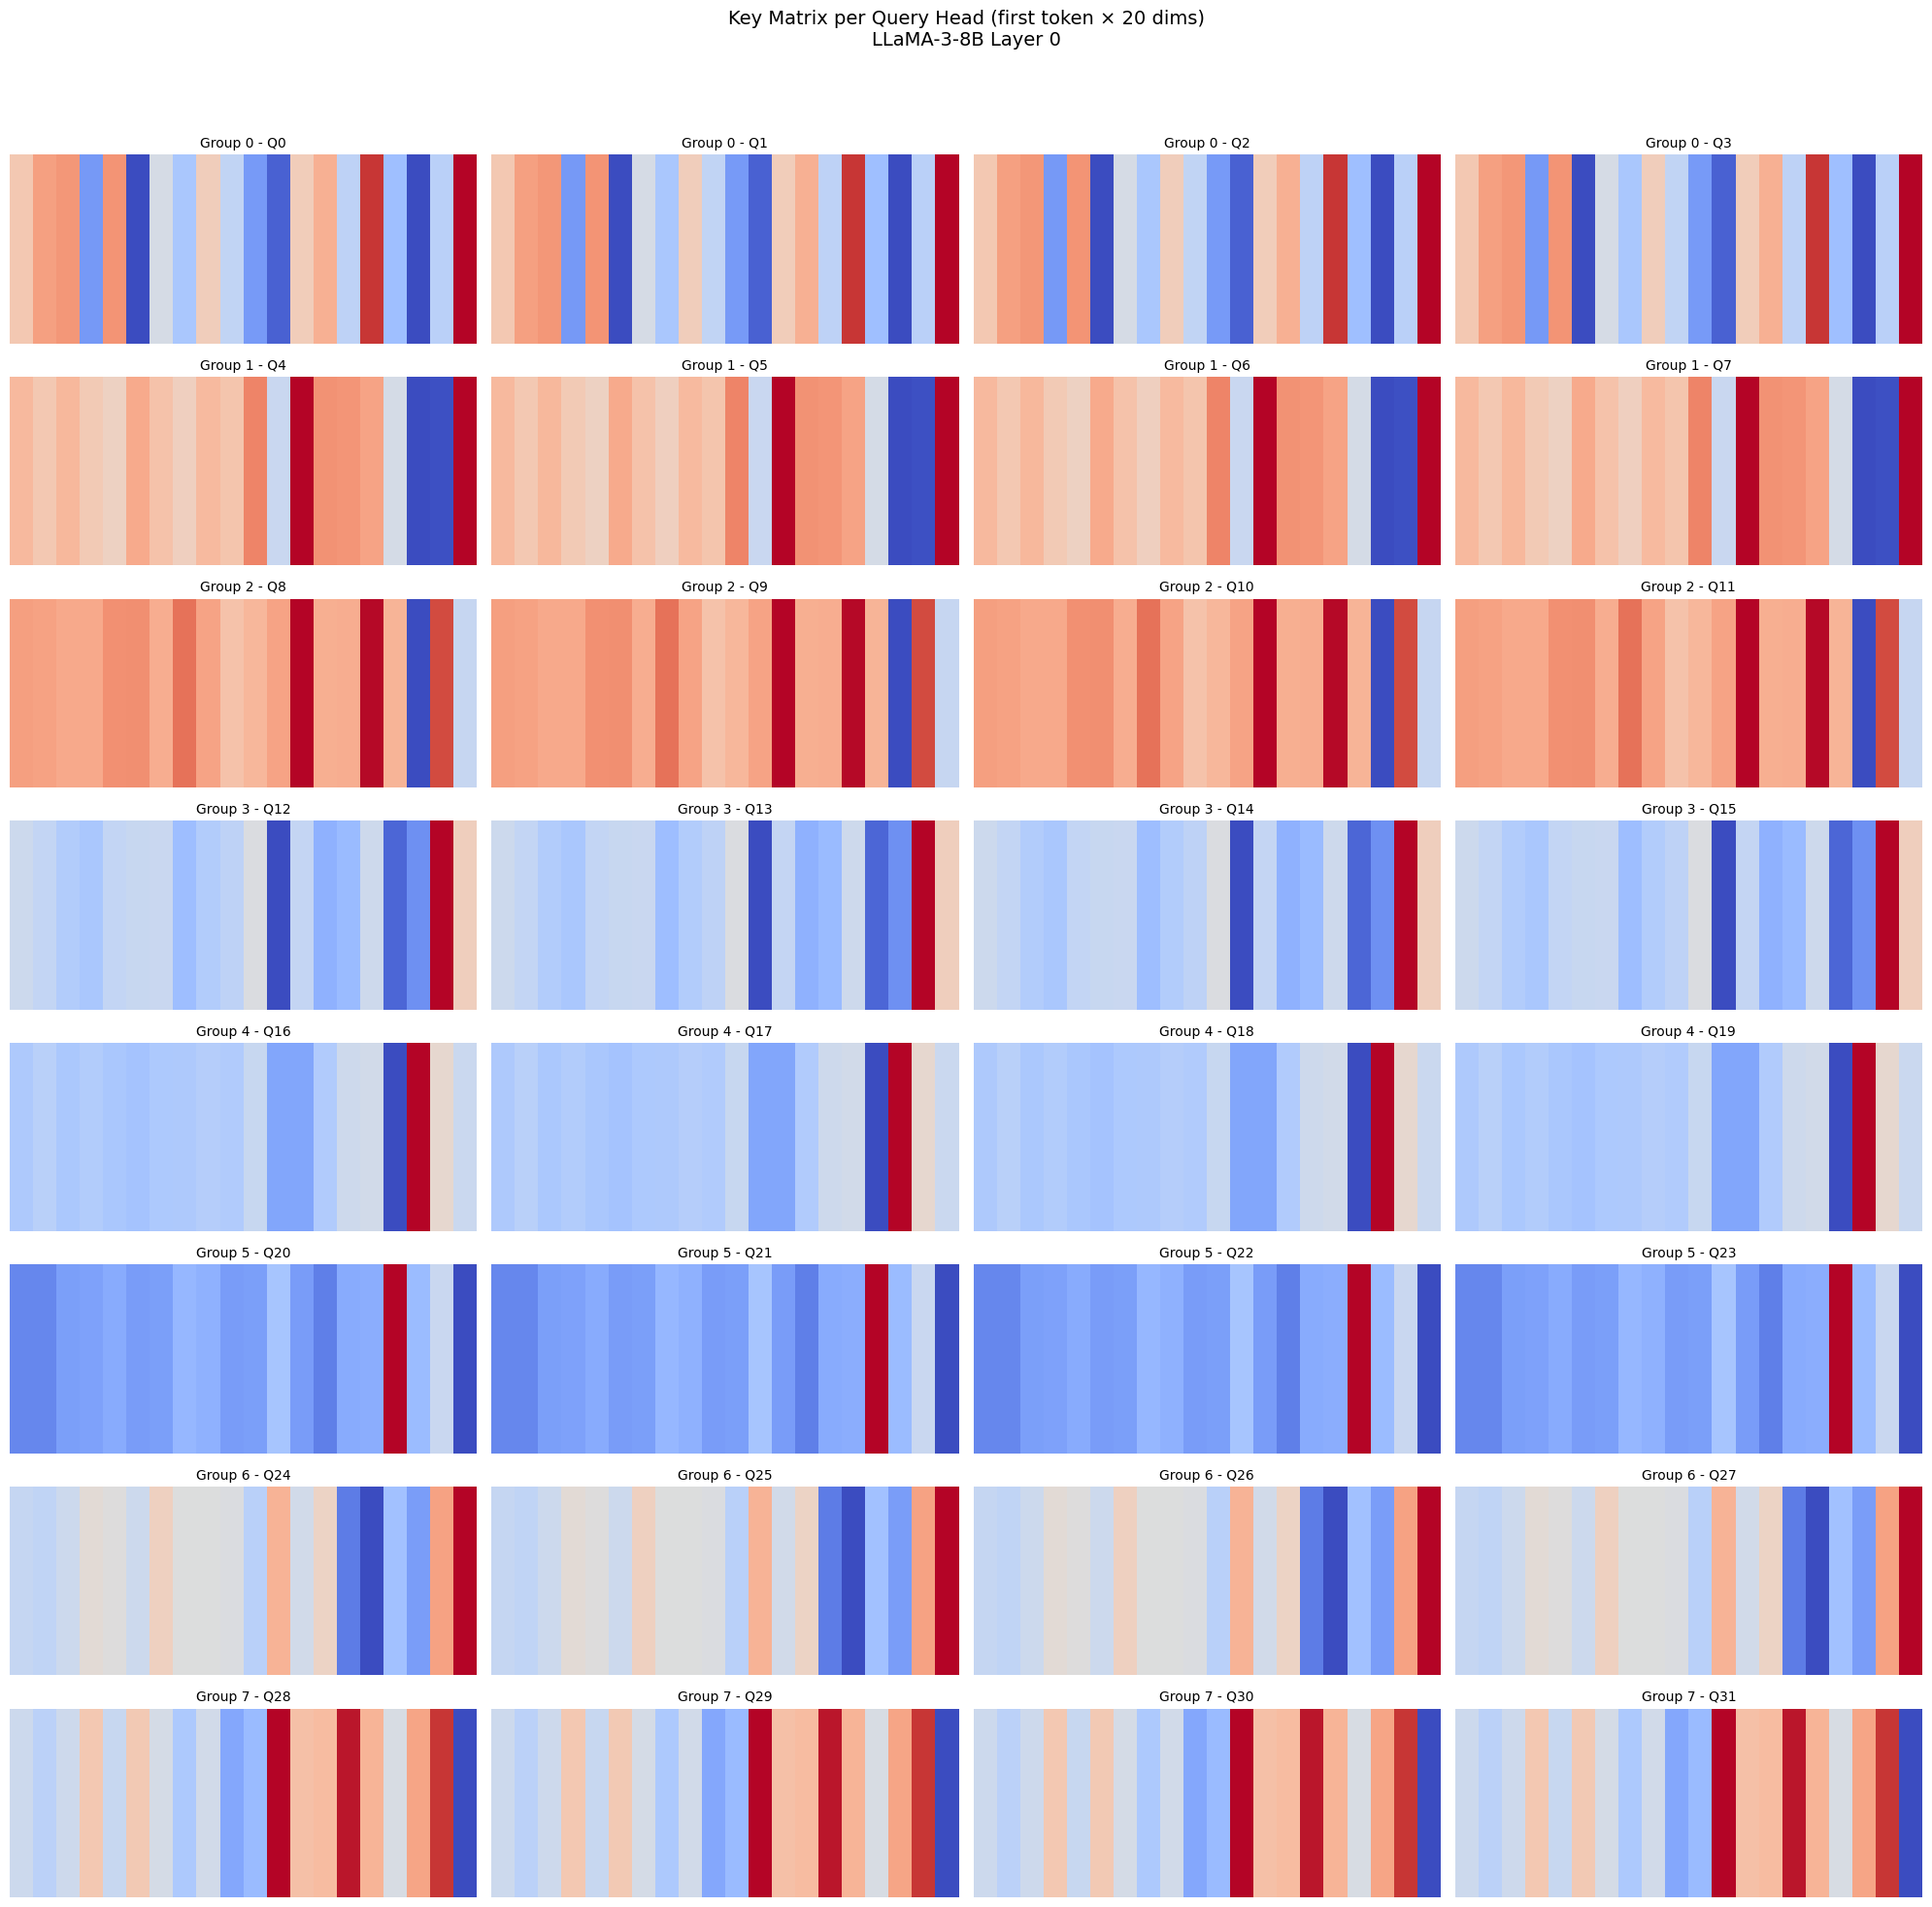

In [5]:
visualize_gqa_keys_correct_mapping(input = "Test to check the Group Quey attention")
